In [53]:
import numpy as np
from uncertainties import ufloat
from uncertainties import unumpy as unp
from scipy.stats import sem
import scipy
from matplotlib import pyplot as plt


In [54]:
fProbe_12cm = ufloat(630.984, 1)/1e-9      # m
fKuv_15mm = np.array([58702.34, 58365.19, 58420.15, 58339.93, 58326.1])
fKuv_30mm = np.array([39951.62, 39866.88, 39830.16, 39840.11, 39834.7])
fKuv_60mm = np.array([15252.72, 15247.69, 15234.79, 15240.33, 15291.63])
fKuv_120mm = np.array([472.98, 490.95, 474.1, 485.87, 471.93])
fKuv_240mm = np.array([])

In [55]:
def lin_func(x, m, b):
    return m*x + b

def typst_tabelle(a):
    collums = len(a)
    rows = len(a[0])
    code = ""
    
    for i in range(rows):
        for j in range(collums):
            code = code  + "[$" + str(a[j][i]) + "$]" + ","
    
    code = code.replace("+/-", " plus.minus ")
    
    
    return ("collums: ", collums, "Tabelle:", code)

def sigma_abw(a,b):
    return (unp.nominal_values(a)-abs(unp.nominal_values(b)))/unp.sqrt(unp.std_devs(a)**2+unp.std_devs(b)**2)

# Länge

(6.285+/-0.021)e+04 (4.413+/-0.011)e+04 (1.885+/-0.011)e+04 (3.8+/-0.5)e+03 242+/-34
[-0.11445826  4.97974834]


114458.26127651552+/-639.9053987283143

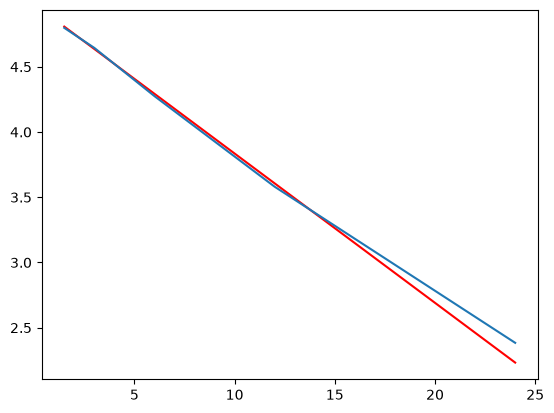

In [61]:
Probe_12cm = ufloat(630.984, 1)/1e-9      # m

c = 10**(-6)

D_mk_24 = ufloat(1.95, 0.1)
D_mk_12 = ufloat(2.01, 0.1)
D_ok = ufloat(2.14, 0.1)

Kuv_15mm = np.array([63281.62, 62641.53, 63341.58, 62201.05, 62786.88])
Kuv_30mm = np.array([44416.39, 43977.27, 44311.21, 43806.47, 44117.39])
Kuv_60mm = np.array([19107.86, 18570.36, 18969.08, 18575.83, 19017.58])
Kuv_120mm = np.array([4440.67, 4180.24, 4385.03, 4172.41, 4397.95])
Kuv_240mm = np.array([291.84, 294.79, 289.23, 294.65, 288.37])

Kuv_15fin = ufloat(np.average(Kuv_15mm),sem(Kuv_15mm))
Kuv_30fin = ufloat(np.average(Kuv_30mm),sem(Kuv_30mm))
Kuv_60fin = ufloat(np.average(Kuv_60mm),sem(Kuv_60mm))
Kuv_120fin = ufloat(np.average(Kuv_120mm),sem(Kuv_120mm))*(D_mk_12**2) /(D_ok**2)
Kuv_240fin = ufloat(np.average(Kuv_240mm),sem(Kuv_240mm))*(D_mk_24**2) /(D_ok**2)

Kuvs = np.array([Kuv_15fin, Kuv_30fin, Kuv_60fin, Kuv_120fin, Kuv_240fin])
längen = np.array([15,30,60,120,240])/10 #in cm


print(Kuv_15fin, Kuv_30fin, Kuv_60fin, Kuv_120fin, Kuv_240fin)

values, errors = scipy.optimize.curve_fit(lin_func, längen, unp.nominal_values(unp.log10(Kuvs)), sigma=unp.std_devs(unp.log10(Kuvs)), absolute_sigma=True)
errors = np.sqrt(np.diag(errors))


plt.plot(längen, lin_func(längen, *values), label='Fit', color='red')

plt.plot(längen, unp.nominal_values(unp.log10(Kuvs)))
print(values)

k_ = ufloat(-values[0], errors[0])

epsilon_len = k_/c  #in L/(mol cm)

epsilon_len


#typst_tabelle([längen, Kuvs])


# Konzentration

0 (3.13+/-0.21)e-06 (6.25+/-0.26)e-06 (1.250+/-0.023)e-05 (2.500+/-0.012)e-05
[-1.57468264e+04  4.80059470e+00]
10498+/-15 (8.9+/-3.1)e+04 (-7.8+/-3.1)e+04 -2.498673561182329


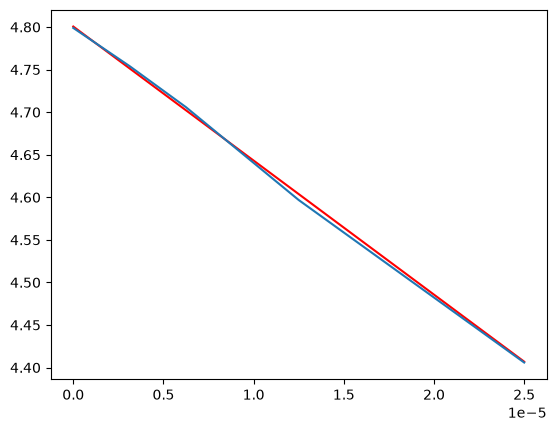

In [86]:
länge2 = 1.5 #cm

V_0 = 21
V_1 = ufloat(1.4, 0.1)
V_2 = ufloat(1.6, 0.1)
V_3 = ufloat(4, 0.1)
V_4 = ufloat(14, 0.1)

c_schlange = 5*10**(-5)

c_0 = 0
c_1 = c_schlange * (V_1/(V_1 + V_0))
c_2 = c_schlange * (V_1 + V_2)/(V_1 + V_2 + V_0)
c_3 = c_schlange * (V_1 + V_2 + V_3)/(V_3 + V_2 + V_1 + V_0)
c_4 = c_schlange * (V_4 + V_3 + V_2 + V_1)/(V_4 + V_3 + V_2 + V_1 + V_0)





mess_c_0 = np.array([63006.98, 62948.3, 62932.78, 62863.46, 62976.22])
mess_c_1 = np.array([56713.88, 56944.97, 56815.91, 56643.26, 56699.21])
mess_c_2 = np.array([50741.22, 50807.88, 50831.03, 50860.73, 50745.46])
mess_c_3 = np.array([39593.13, 39607.11, 39469.71, 39493.06, 39425.11])
mess_c_4 = np.array([25419.88, 25514.51, 25302.96, 25510.69, 25563.66])



c_1_fin = ufloat(np.average(mess_c_0),sem(mess_c_0))
c_2_fin = ufloat(np.average(mess_c_1),sem(mess_c_1))
c_3_fin = ufloat(np.average(mess_c_2),sem(mess_c_2))
c_4_fin = ufloat(np.average(mess_c_3),sem(mess_c_3))
c_5_fin = ufloat(np.average(mess_c_4),sem(mess_c_4))

c_fin_s = np.array([c_1_fin, c_2_fin, c_3_fin, c_4_fin, c_5_fin])
c_s = np.array([c_0, c_1, c_2, c_3, c_4])


#print(c_1_fin, c_2_fin, c_3_fin, c_4_fin, c_5_fin)
print(c_0, c_1, c_2, c_3, c_4)

values_c, errors_c = scipy.optimize.curve_fit(lin_func, unp.nominal_values(c_s), unp.nominal_values(unp.log10(c_fin_s)), sigma = unp.std_devs(unp.log10(c_fin_s)), absolute_sigma=True)
errors_c = np.sqrt(np.diag(errors_c))



plt.plot(unp.nominal_values(c_s), lin_func(unp.nominal_values(c_s), *values_c), label='Fit', color='red')


plt.plot( unp.nominal_values(c_s), unp.nominal_values(unp.log10(c_fin_s)))


print(values_c)



k_c = ufloat(-values_c[0], errors_c[0])

epsilon_c = k_c/länge2 #in L/(mol cm)




Abstand_epsi = epsilon_c - epsilon_len



print(epsilon_c, epsilon_len, Abstand_epsi, sigma_abw(epsilon_c, epsilon_len))


#typst_tabelle([c_s, c_fin_s])


In [70]:
m1  = (np.log10(3.1e4)-np.log10(2.8e2))/(27-4)
mf1 = (np.log10(3.1e4)-np.log10(2.8e2))/(21-4)-m1
m1 = ufloat(m1, mf1)
m2  = (np.log10(5.5e4)-np.log10(2.6e4))/(25.2e-7 - 3e-7)
mf2 = (np.log10(5.5e4)-np.log10(2.6e4))/(24e-7 - 3e-7)-m2
m2 = ufloat(m2, mf2)
m1,m2

(0.08887842010835016+/-0.03136885415588829,
 146571.77546100266+/-8375.53002634304)

In [82]:

epsilon_len2 = m1/c  #in L/(mol cm)


epsilon_c2 = m2/länge2 #in L/(mol cm)


epsilon_c2, epsilon_len2, sigma_abw(epsilon_c2, epsilon_len2)

(97714.51697400177+/-5583.686684228693,
 88878.42010835017+/-31368.85415588829,
 0.2773245981071029)

In [80]:
mx  = -(np.log10(5.2e4)-np.log10(2e4))/(0-2.5e-6)
mfx = (np.log10(3.1e4)-np.log10(2.8e2))/(21-4)-m1
mx

np.float64(165989.33918832726)